# Results analysis

Reads the result CSVs in `results/tables`, prints the results tables and saves the figures to `results/plots`.

Only runs with the main settings are used (10 clients, 1 local epoch, lr 0.003 for the hybrid model and 0.001 for the classical CNN), so the tuning and test runs are skipped.

In [12]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy import stats

%matplotlib inline

In [13]:
TABLES_DIR = "../results/tables"
PLOTS_DIR  = "../results/plots"

CLIENTS      = 10
EPOCHS       = 1
LR           = 0.003
CLASSICAL_LR = 0.001
MU           = 0.01
TARGET       = 75
MAIN_SPLITS  = ["IID", "Dirichlet α=0.5", "Dirichlet α=0.1"]

PATTERN = re.compile(r"^(classical|qfl_fedavg|qfl_fedprox_full|qfl_fedprox|qfl_weighted)_(iid|dirichlet)_a([\d.]+)"
                     r"(?:_mu([\d.e-]+))?(?:_lam([\d.]+))?_c(\d+)_e(\d+)_lr([\d.e-]+)_s(\d+)\.csv$")

NAMES = {
    "qfl_fedavg":       "QFL FedAvg",
    "qfl_fedprox":      "Quantum FedProx",
    "qfl_fedprox_full": "Full FedProx",
    "qfl_weighted":     "Weighted Agg",
    "classical":        "Classical FedAvg",
}
ORDER  = ["QFL FedAvg", "Quantum FedProx", "Full FedProx", "Weighted Agg", "Classical FedAvg"]
COLORS = {"QFL FedAvg": "#7f7f7f", "Quantum FedProx": "#d62728", "Full FedProx": "#ff7f0e",
          "Weighted Agg": "#1f77b4", "Classical FedAvg": "#2ca02c"}

os.makedirs(PLOTS_DIR, exist_ok=True)

## Load the runs

In [14]:
rows = []
for fname in sorted(os.listdir(TABLES_DIR)):
    match = PATTERN.match(fname)
    if not match:
        continue
    kind, partition, alpha, mu, lam, clients, epochs, lr, seed = match.groups()
    want_lr = CLASSICAL_LR if kind == "classical" else LR
    if int(clients) != CLIENTS or int(epochs) != EPOCHS or float(lr) != want_lr:
        continue

    df = pd.read_csv(os.path.join(TABLES_DIR, fname))
    acc = df["accuracy"] * 100
    rows.append({
        "strategy": NAMES[kind],
        "split": "IID" if partition == "iid" else f"Dirichlet α={float(alpha):g}",
        "mu": float(mu) if mu else np.nan,
        "seed": int(seed),
        "emd": df["emd"].iloc[0],
        "rounds": len(df),
        "final": acc.iloc[-1],
        "last5": acc.iloc[-5:].mean(),
        "best": acc.max(),
        "sec_per_round": df["time"].mean(),
        "curve": acc.tolist(),
    })

runs = pd.DataFrame(rows)
main = runs[runs["mu"].isna() | (runs["mu"] == MU)]
splits = main.groupby("split")["emd"].mean().sort_values().index.tolist()
strategies = [s for s in ORDER if s in set(main["strategy"])]
print(f"Loaded {len(runs)} runs ({len(main)} in the main comparison)")

Loaded 87 runs (76 in the main comparison)


## Results table

Test accuracy (%) averaged over the last 5 rounds. When a setting has more than one seed the cell shows mean ± std over seeds, `-` means that run was not done.

In [15]:
summary = (main.groupby(["split", "strategy"])
           .agg(emd=("emd", "mean"), seeds=("seed", "nunique"), last5=("last5", "mean"),
                last5_std=("last5", "std"), final=("final", "mean"), best=("best", "mean"),
                sec_per_round=("sec_per_round", "mean"))
           .reset_index())
summary["last5_std"] = summary["last5_std"].fillna(0)
summary["split_order"] = summary["split"].map({s: i for i, s in enumerate(splits)})
summary["strategy_order"] = summary["strategy"].map({s: i for i, s in enumerate(ORDER)})
summary = (summary.sort_values(["split_order", "strategy_order"])
           .drop(columns=["split_order", "strategy_order"]).reset_index(drop=True))
summary.to_csv(os.path.join(TABLES_DIR, "summary.csv"), index=False)

print("| Split | EMD | " + " | ".join(strategies) + " |")
print("|---" * (len(strategies) + 2) + "|")
for split in splits:
    sub = summary[summary["split"] == split].set_index("strategy")
    cells = []
    for strategy in strategies:
        if strategy not in sub.index:
            cells.append("-")
        elif sub.loc[strategy, "seeds"] > 1:
            cells.append(f"{sub.loc[strategy, 'last5']:.2f} ± {sub.loc[strategy, 'last5_std']:.2f}")
        else:
            cells.append(f"{sub.loc[strategy, 'last5']:.2f}")
    print(f"| {split} | {sub['emd'].mean():.3f} | " + " | ".join(cells) + " |")

| Split | EMD | QFL FedAvg | Quantum FedProx | Full FedProx | Weighted Agg | Classical FedAvg |
|---|---|---|---|---|---|---|
| IID | 0.040 | 85.28 ± 3.17 | 85.16 ± 3.42 | 83.45 ± 4.60 | 85.03 ± 3.40 | 90.14 ± 0.22 |
| Dirichlet α=1 | 1.080 | 79.56 | 79.35 | - | - | - |
| Dirichlet α=0.5 | 1.214 | 77.24 ± 10.78 | 76.37 ± 10.42 | 78.70 ± 6.84 | 78.33 ± 8.39 | 88.93 ± 0.60 |
| Dirichlet α=0.3 | 1.324 | 85.53 | 85.84 | - | - | - |
| Dirichlet α=0.2 | 1.573 | 64.36 | 67.06 | - | - | - |
| Dirichlet α=0.1 | 1.700 | 43.61 ± 5.62 | 43.76 ± 9.28 | 49.07 ± 12.74 | 40.05 ± 7.89 | 82.24 ± 2.66 |


Every run on its own (last 5 rounds mean, one column per seed):

In [16]:
per_seed = main.pivot_table(index=["split", "strategy"], columns="seed", values="last5")
order = [(sp, st) for sp in splits for st in strategies if (sp, st) in per_seed.index]
per_seed.loc[order].round(2).fillna("")

seed                                 42     43     44     45     46     47  \
split           strategy                                                     
IID             QFL FedAvg        86.98  87.24  81.62                        
                Quantum FedProx   86.89  87.38  81.23                        
                Full FedProx      85.58   86.6  78.17                        
                Weighted Agg      86.77   87.2  81.11                        
                Classical FedAvg  89.90  90.17  90.35                        
Dirichlet α=1   QFL FedAvg        79.56                                      
                Quantum FedProx   79.35                                      
Dirichlet α=0.5 QFL FedAvg        86.36  65.35  80.02                        
                Quantum FedProx   86.72  65.89   76.5                        
                Full FedProx      86.38  73.28  76.44                        
                Weighted Agg      85.56  69.13  80.31                        
                Classical FedAvg  89.60  88.45  88.73                        
Dirichlet α=0.3 QFL FedAvg        85.53                                      
                Quantum FedProx   85.84                                      
Dirichlet α=0.2 QFL FedAvg        64.36                                      
                Quantum FedProx   67.06                                      
Dirichlet α=0.1 QFL FedAvg        44.33  37.12  45.01  46.46  50.04  47.34   
                Quantum FedProx   57.54  34.54  45.11  50.75  31.79  49.25   
                Full FedProx      54.78  47.42  45.84  49.91   47.9  59.21   
                Weighted Agg      48.07  35.71  45.88  35.93  43.84  46.02   
                Classical FedAvg  84.88  76.34  82.38  82.29  84.64  82.06   

seed                                 48     49  
split           strategy                        
IID             QFL FedAvg                      
                Quantum FedProx                 
                Full FedProx                    
                Weighted Agg                    
                Classical FedAvg                
Dirichlet α=1   QFL FedAvg                      
                Quantum FedProx                 
Dirichlet α=0.5 QFL FedAvg                      
                Quantum FedProx                 
                Full FedProx                    
                Weighted Agg                    
                Classical FedAvg                
Dirichlet α=0.3 QFL FedAvg                      
                Quantum FedProx                 
Dirichlet α=0.2 QFL FedAvg                      
                Quantum FedProx                 
Dirichlet α=0.1 QFL FedAvg        33.13  45.41  
                Quantum FedProx   34.07  46.99  
                Full FedProx      22.18  65.29  
                Weighted Agg       24.2  40.73  
                Classical FedAvg  81.79  83.53

## Gain over QFL FedAvg on the same seeds

For every strategy, its last-5 accuracy minus QFL FedAvg's on the same seed. The same seed means the same client split and the same starting weights, so the difference comes from the method only. `better_on` counts the seeds where the strategy beat FedAvg, and `p_value` is a two-sided paired t-test (mean gain = 0). Every μ is listed, so the μ sweep runs show up here too.

In [17]:
fedavg = runs[runs["strategy"] == "QFL FedAvg"].set_index(["split", "seed"])["last5"]
others = runs[~runs["strategy"].isin(["QFL FedAvg", "Classical FedAvg"])]

gain_rows = []
for (split, strategy, mu), sub in others.groupby(["split", "strategy", "mu"], dropna=False):
    gain = (sub.set_index("seed")["last5"] - fedavg.loc[split]).dropna()
    gain_rows.append({
        "split": split,
        "strategy": strategy,
        "mu": mu,
        "seeds": len(gain),
        "mean_gain": gain.mean(),
        "std": gain.std(),
        "better_on": f"{(gain > 0).sum()}/{len(gain)}",
        "p_value": stats.ttest_1samp(gain, 0).pvalue if len(gain) > 1 else np.nan,
    })

gains = pd.DataFrame(gain_rows)
gains["split_order"] = gains["split"].map({s: i for i, s in enumerate(splits)})
gains["strategy_order"] = gains["strategy"].map({s: i for i, s in enumerate(ORDER)})
gains = (gains.sort_values(["split_order", "strategy_order", "mu"])
         .drop(columns=["split_order", "strategy_order"]).reset_index(drop=True))
gains.to_csv(os.path.join(TABLES_DIR, "paired_gains.csv"), index=False)

gains.round({"mean_gain": 2, "std": 2, "p_value": 3}).fillna("")

,split,strategy,mu,seeds,mean_gain,std,better_on,p_value
0,IID,Quantum FedProx,0.01,3,-0.12,0.26,1/3,0.529
1,IID,Full FedProx,0.01,3,-1.83,1.45,0/3,0.161
2,IID,Weighted Agg,,3,-0.25,0.24,0/3,0.207
3,Dirichlet α=1,Quantum FedProx,0.01,1,-0.21,,0/1,
4,Dirichlet α=0.5,Quantum FedProx,0.01,3,-0.87,2.3,2/3,0.577
5,Dirichlet α=0.5,Full FedProx,0.01,3,1.46,5.89,2/3,0.71
6,Dirichlet α=0.5,Weighted Agg,,3,1.09,2.39,2/3,0.512
7,Dirichlet α=0.3,Quantum FedProx,0.01,1,0.31,,1/1,
8,Dirichlet α=0.2,Quantum FedProx,0.01,1,2.70,,1/1,
9,Dirichlet α=0.1,Quantum FedProx,0.001,1,14.46,,1/1,


Rounds until the mean accuracy curve (over seeds) first reaches the target, blank means it never did:

In [18]:
reach = {}
for (split, strategy), sub in main.groupby(["split", "strategy"]):
    n = min(len(c) for c in sub["curve"])
    mean_curve = np.mean([c[:n] for c in sub["curve"]], axis=0)
    hit = np.where(mean_curve >= TARGET)[0]
    reach[(split, strategy)] = hit[0] + 1 if len(hit) else np.nan

print(f"Target = {TARGET:g}% test accuracy")
pd.Series(reach).unstack().reindex(index=splits, columns=strategies).fillna("")

Target = 75% test accuracy


,QFL FedAvg,Quantum FedProx,Full FedProx,Weighted Agg,Classical FedAvg
IID,7.0,7.0,8.0,7.0,1.0
Dirichlet α=1,14.0,15.0,,,
Dirichlet α=0.5,17.0,17.0,15.0,16.0,2.0
Dirichlet α=0.3,9.0,10.0,,,
Dirichlet α=0.2,,,,,
Dirichlet α=0.1,,,,,7.0


## Accuracy per round

Mean over seeds, the shaded band is ±1 std.

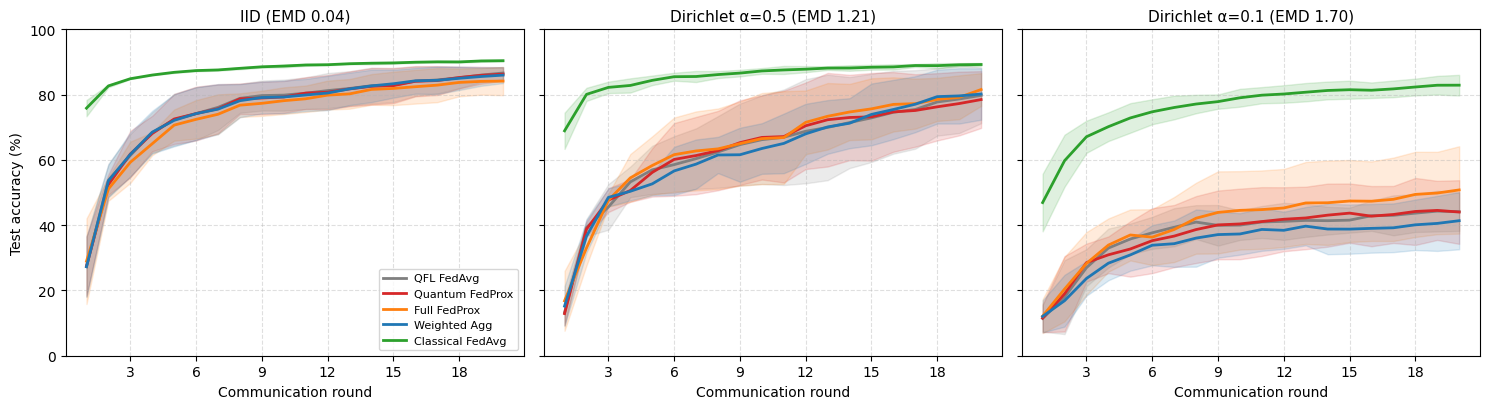

Saved: ../results/plots\accuracy_curves.png


In [19]:
fig, axes = plt.subplots(1, len(MAIN_SPLITS), figsize=(5 * len(MAIN_SPLITS), 4.2), sharey=True)
axes = np.atleast_1d(axes)
for ax, split in zip(axes, MAIN_SPLITS):
    for strategy in ORDER:
        sub = main[(main["split"] == split) & (main["strategy"] == strategy)]
        if sub.empty:
            continue
        n = min(len(c) for c in sub["curve"])
        curves = np.array([c[:n] for c in sub["curve"]])
        mean = curves.mean(axis=0)
        rounds = np.arange(1, n + 1)
        ax.plot(rounds, mean, label=strategy, color=COLORS[strategy], lw=2)
        if len(curves) > 1:
            std = curves.std(axis=0, ddof=1)
            ax.fill_between(rounds, mean - std, mean + std, color=COLORS[strategy], alpha=0.15)
    emd = main[main["split"] == split]["emd"].mean()
    ax.set_title(f"{split} (EMD {emd:.2f})", fontsize=11)
    ax.set_xlabel("Communication round")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylim(0, 100)
    ax.grid(True, ls="--", alpha=0.4)
axes[0].set_ylabel("Test accuracy (%)")
axes[0].legend(fontsize=8, loc="lower right")
fig.tight_layout()

out = os.path.join(PLOTS_DIR, "accuracy_curves.png")
fig.savefig(out, dpi=200)
plt.show()
print(f"Saved: {out}")

## Accuracy vs measured non-IID level

Each point is one run. The x axis is the EMD proxy measured on that run's client split (0 = every client has the same label mix, 2 = no two clients share a class).

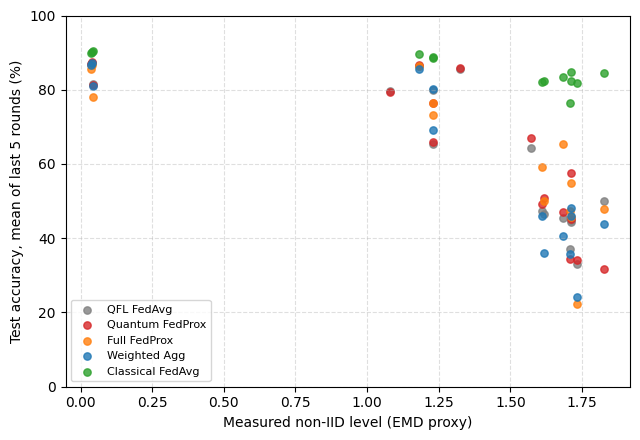

Saved: ../results/plots\accuracy_vs_emd.png


In [20]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for strategy in strategies:
    sub = main[main["strategy"] == strategy]
    ax.scatter(sub["emd"], sub["last5"], label=strategy, color=COLORS[strategy], s=28, alpha=0.8)
ax.set_xlabel("Measured non-IID level (EMD proxy)")
ax.set_ylabel("Test accuracy, mean of last 5 rounds (%)")
ax.set_ylim(0, 100)
ax.grid(True, ls="--", alpha=0.4)
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()

out = os.path.join(PLOTS_DIR, "accuracy_vs_emd.png")
fig.savefig(out, dpi=200)
plt.show()
print(f"Saved: {out}")

## Strategy comparison

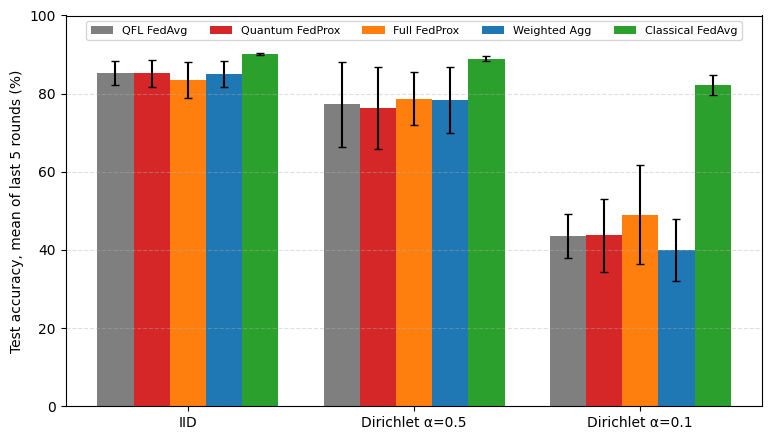

Saved: ../results/plots\strategy_comparison.png


In [21]:
width = 0.8 / len(strategies)
x = np.arange(len(MAIN_SPLITS))
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, strategy in enumerate(strategies):
    sub = summary[summary["strategy"] == strategy].set_index("split").reindex(MAIN_SPLITS)
    ax.bar(x - 0.4 + width * (i + 0.5), sub["last5"], width, yerr=sub["last5_std"],
           label=strategy, color=COLORS[strategy], capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(MAIN_SPLITS)
ax.set_ylabel("Test accuracy, mean of last 5 rounds (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=8, ncol=len(strategies), loc="upper center")
fig.tight_layout()

out = os.path.join(PLOTS_DIR, "strategy_comparison.png")
fig.savefig(out, dpi=200)
plt.show()
print(f"Saved: {out}")

## Proximal strength sweep

Same-seed gain over QFL FedAvg against μ, for Quantum FedProx and Full FedProx at the strongest skew. Every seed is used: each run is compared with FedAvg on its own seed, so points with a different number of seeds (n) can sit on one plot. Error bars are the std of the gain, and the dashed line is FedAvg itself (gain 0).

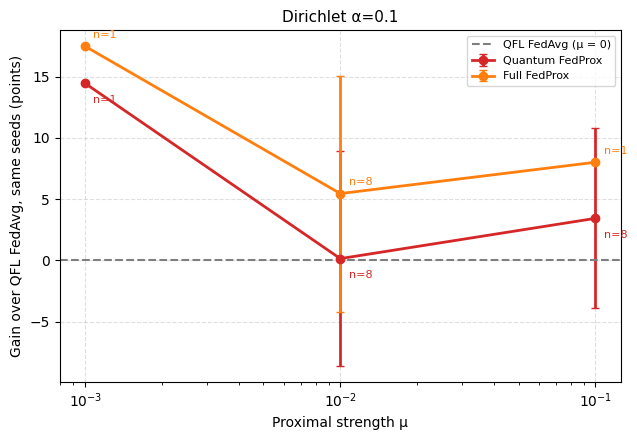

Saved: ../results/plots\mu_sweep.png


,strategy,mu,seeds,mean_gain,std,better_on,p_value
9,Quantum FedProx,0.001,1,14.46,,1/1,
10,Quantum FedProx,0.010,8,0.15,8.78,6/8,0.963
11,Quantum FedProx,0.100,8,3.44,7.35,5/8,0.228
12,Full FedProx,0.001,1,17.48,,1/1,
13,Full FedProx,0.010,8,5.46,9.63,6/8,0.153
14,Full FedProx,0.100,1,8.02,,1/1,


In [22]:
split = splits[-1]
sweep = gains[(gains["split"] == split) & gains["strategy"].isin(["Quantum FedProx", "Full FedProx"])]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for strategy, offset in [("Quantum FedProx", -14), ("Full FedProx", 6)]:
    sub = sweep[sweep["strategy"] == strategy].sort_values("mu")
    ax.errorbar(sub["mu"], sub["mean_gain"], yerr=sub["std"].fillna(0), label=strategy,
                color=COLORS[strategy], marker="o", lw=2, capsize=3)
    for mu, g, n in zip(sub["mu"], sub["mean_gain"], sub["seeds"]):
        ax.annotate(f"n={n}", (mu, g), textcoords="offset points", xytext=(6, offset),
                    fontsize=8, color=COLORS[strategy])
ax.axhline(0, color=COLORS["QFL FedAvg"], ls="--", label="QFL FedAvg (μ = 0)")
ax.set_xscale("log")
ax.set_xlabel("Proximal strength μ")
ax.set_ylabel("Gain over QFL FedAvg, same seeds (points)")
ax.set_title(split, fontsize=11)
ax.grid(True, ls="--", alpha=0.4)
ax.legend(fontsize=8)
fig.tight_layout()

out = os.path.join(PLOTS_DIR, "mu_sweep.png")
fig.savefig(out, dpi=200)
plt.show()
print(f"Saved: {out}")

sweep.drop(columns="split").round({"mean_gain": 2, "std": 2, "p_value": 3}).fillna("")